In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Clean_Dataset_Amazon.csv")

# Display first 5 rows
df.head()


,Brand,Price,Rating,Ram,Color,Processor,Storage_Gb
0,HP,69990.0,3.4,16.0,Silver,Apple M365,512.0
1,Apple,73990.0,4.8,8.0,Silver,Apple A18,256.0
2,Lenovo,44999.0,4.0,8.0,Silver,AMD,512.0
3,ASUS,65990.0,4.1,16.0,Blue,Apple M365,512.0
4,Apple,73990.0,4.7,8.0,Silver,Apple A18,256.0


In [3]:
# Basic information about the dataset
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape: (977, 7)

Columns:
['Brand', 'Price', 'Rating', 'Ram', 'Color', 'Processor', 'Storage_Gb']

Data types:
Brand             str
Price         float64
Rating        float64
Ram           float64
Color             str
Processor         str
Storage_Gb    float64
dtype: object


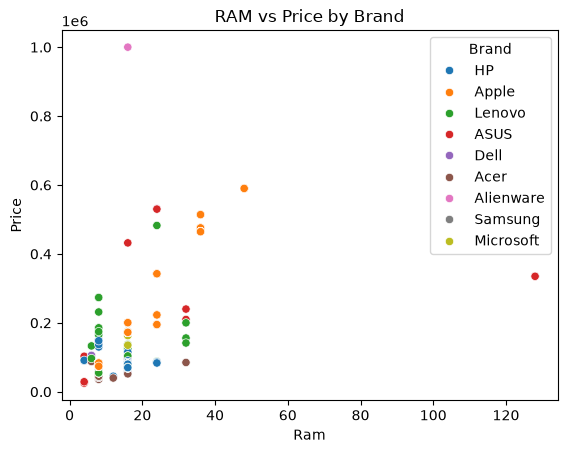

In [4]:
sns.scatterplot(
    data=df,
    x="Ram",
    y="Price",
    hue="Brand"
)

plt.title("RAM vs Price by Brand")
plt.show()

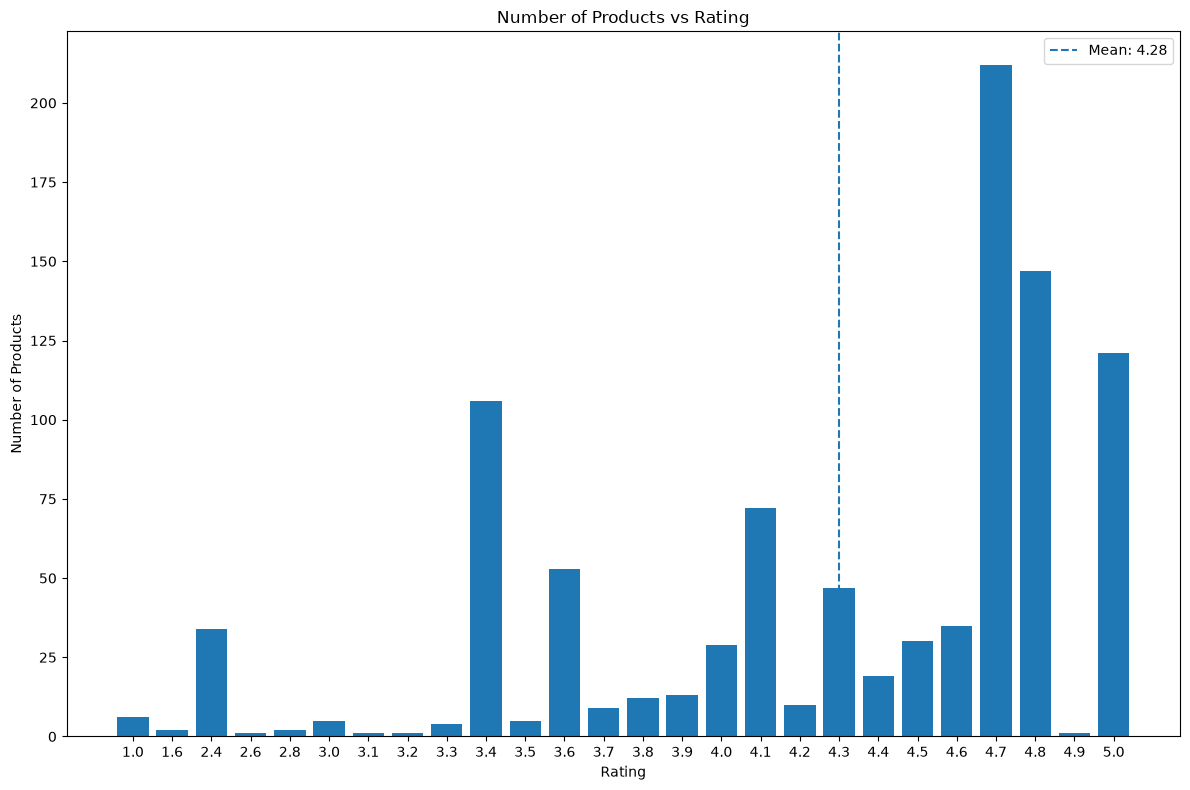

In [5]:
count = df["Rating"].value_counts().sort_index()
mean = df["Rating"].mean()

plt.figure(figsize=(12,8))
plt.bar(count.index.astype(str), count.values)

plt.axvline(
    x=list(count.index).index(round(mean, 1)),
    linestyle="--",
    label=f"Mean: {mean:.2f}"
)

plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Number of Products vs Rating")
plt.legend()
plt.tight_layout()
plt.show()

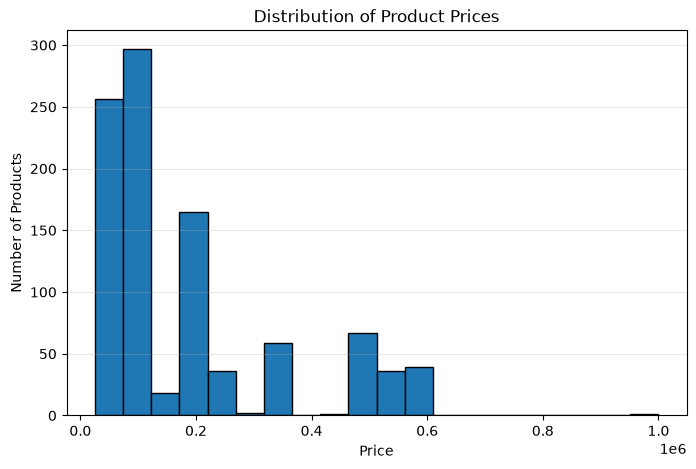

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["Price"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.xlim()
plt.grid(axis="y", alpha=0.3)
plt.show()

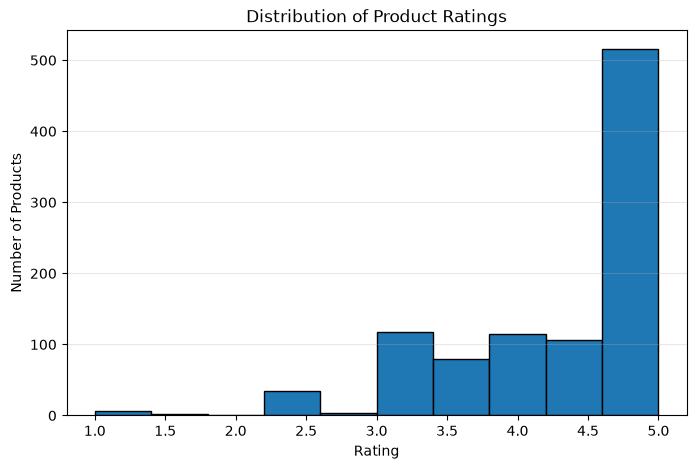

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["Rating"].dropna(), bins=10, edgecolor="black")
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.grid(axis="y", alpha=0.3)
plt.show()

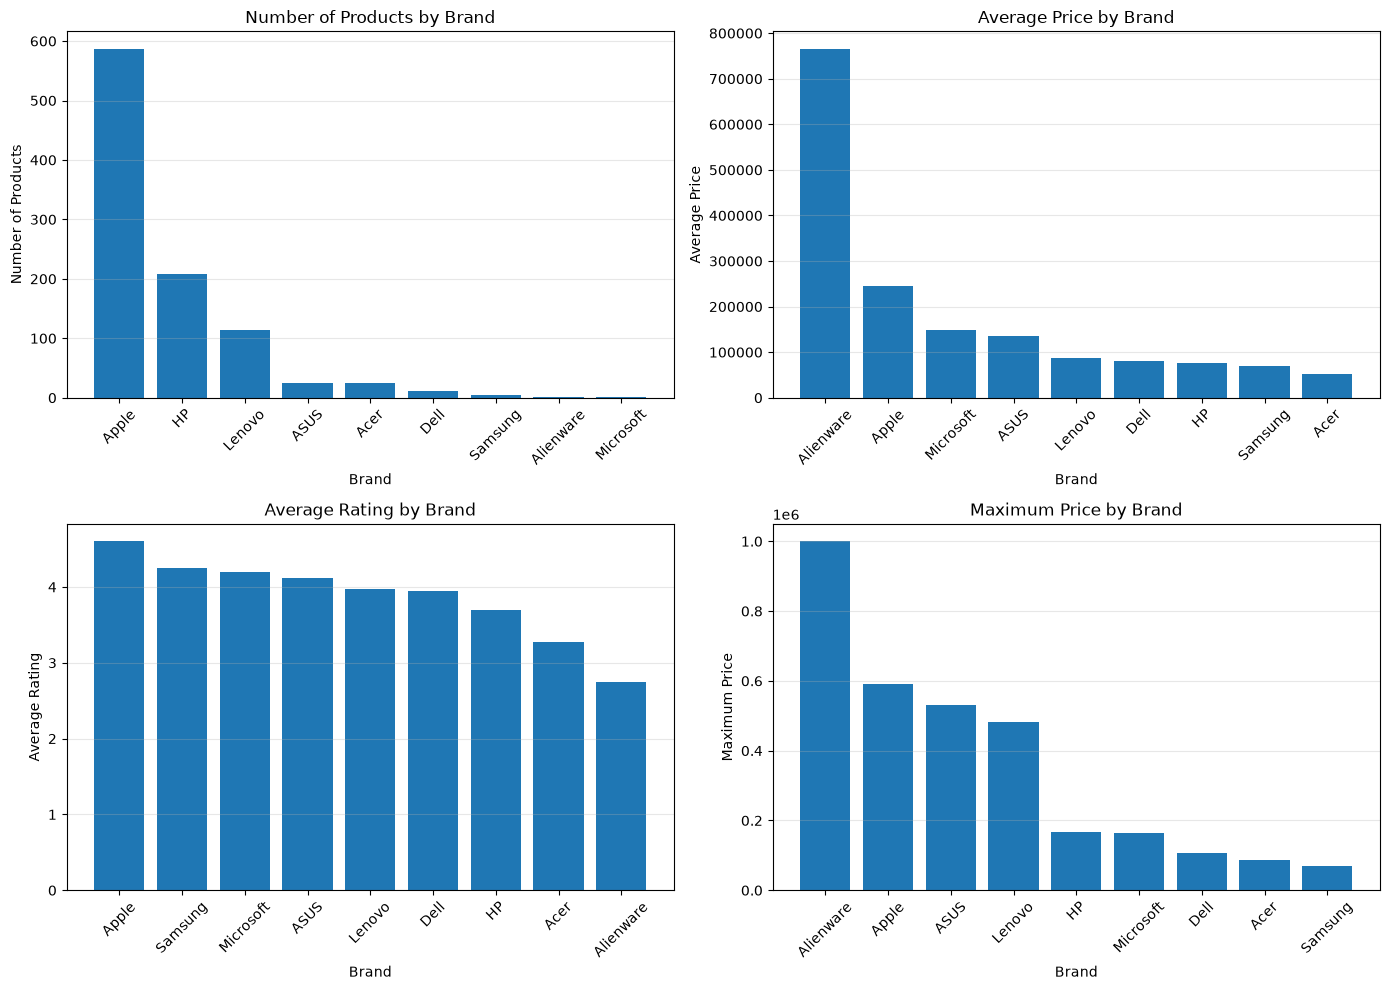

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Number of Products by Brand
brand_counts = df["Brand"].value_counts()
ax[0, 0].bar(brand_counts.index, brand_counts.values)
ax[0, 0].set_title("Number of Products by Brand")
ax[0, 0].set_xlabel("Brand")
ax[0, 0].set_ylabel("Number of Products")
ax[0, 0].tick_params(axis="x", rotation=45)
ax[0, 0].grid(axis="y", alpha=0.3)

# 2. Average Price by Brand
avg_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False)
ax[0, 1].bar(avg_price.index, avg_price.values)
ax[0, 1].set_title("Average Price by Brand")
ax[0, 1].set_xlabel("Brand")
ax[0, 1].set_ylabel("Average Price")
ax[0, 1].tick_params(axis="x", rotation=45)
ax[0, 1].grid(axis="y", alpha=0.3)

# 3. Average Rating by Brand
avg_rating = df.groupby("Brand")["Rating"].mean().sort_values(ascending=False)
ax[1, 0].bar(avg_rating.index, avg_rating.values)
ax[1, 0].set_title("Average Rating by Brand")
ax[1, 0].set_xlabel("Brand")
ax[1, 0].set_ylabel("Average Rating")
ax[1, 0].tick_params(axis="x", rotation=45)
ax[1, 0].grid(axis="y", alpha=0.3)

# 4. Maximum Price by Brand
max_price = df.groupby("Brand")["Price"].max().sort_values(ascending=False)
ax[1, 1].bar(max_price.index, max_price.values)
ax[1, 1].set_title("Maximum Price by Brand")
ax[1, 1].set_xlabel("Brand")
ax[1, 1].set_ylabel("Maximum Price")
ax[1, 1].tick_params(axis="x", rotation=45)
ax[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

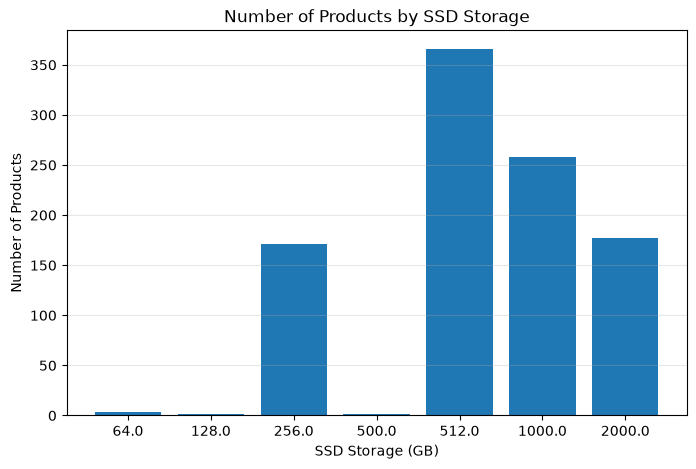

In [9]:
ssd_counts = df["Storage_Gb"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(ssd_counts.index.astype(str), ssd_counts.values)
plt.title("Number of Products by SSD Storage")
plt.xlabel("SSD Storage (GB)")
plt.ylabel("Number of Products")
plt.grid(axis="y", alpha=0.3)
plt.show()

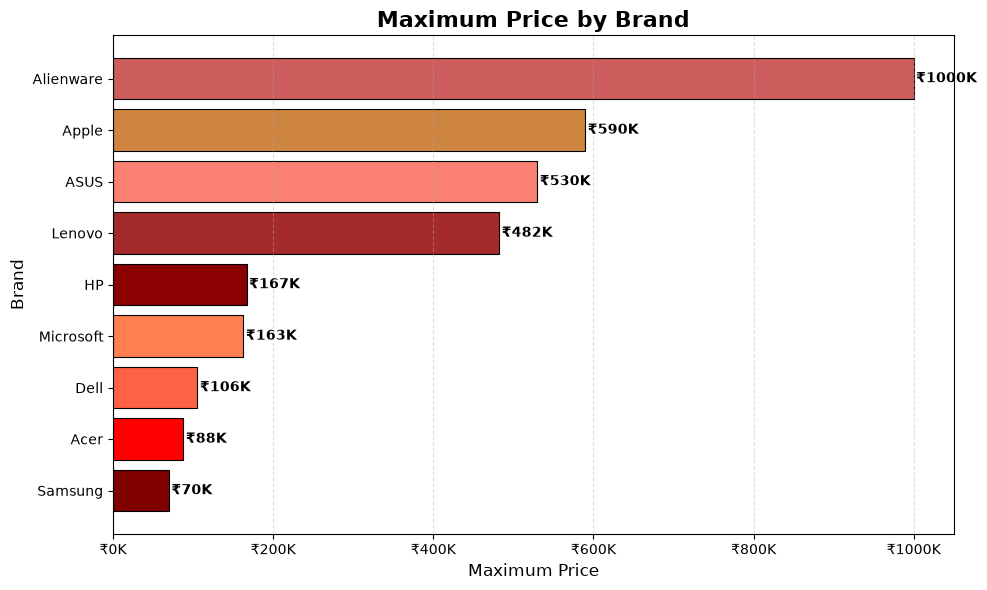

In [10]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 6))

# Maximum price for each brand
brand_price = df.groupby("Brand")["Price"].max().sort_values()

# Colors
colors = [
    "maroon", "red", "tomato", "coral",
    "darkred", "brown", "salmon",
    "peru", "indianred"
]

# Bar chart
bars = ax.barh(
    brand_price.index,
    brand_price.values,
    color=colors[:len(brand_price)],
    edgecolor="black",
    linewidth=0.8
)

# Format X-axis as ₹K
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1000:.0f}K")
)

# Title and labels
ax.set_title(
    "Maximum Price by Brand",
    fontweight="bold",
    fontsize=16
)

ax.set_xlabel("Maximum Price", fontsize=12)
ax.set_ylabel("Brand", fontsize=12)

# Add values at the end of bars
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 3000,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width/1000:.0f}K",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Grid
ax.grid(
    axis="x",
    alpha=0.4,
    linestyle="--"
)


plt.tight_layout()
plt.show()

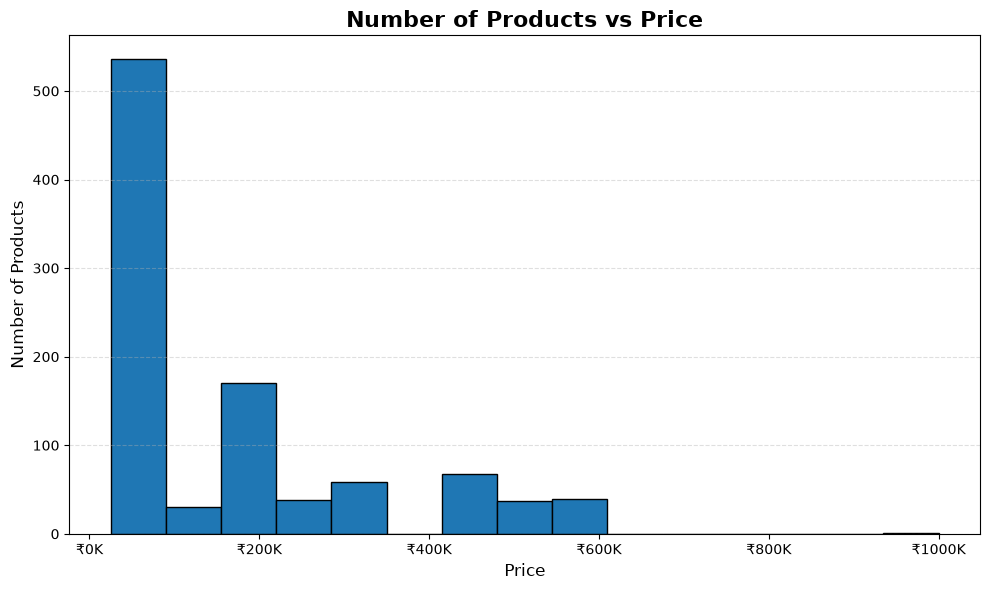

In [11]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["Price"].dropna(),
    bins=15,
    edgecolor="black"
)

# Format price as ₹K
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1000:.0f}K")
)

ax.set_title(
    "Number of Products vs Price",
    fontweight="bold",
    fontsize=16
)

ax.set_xlabel("Price", fontsize=12)
ax.set_ylabel("Number of Products", fontsize=12)

ax.grid(
    axis="y",
    alpha=0.4,
    linestyle="--"
)

plt.tight_layout()
plt.show()

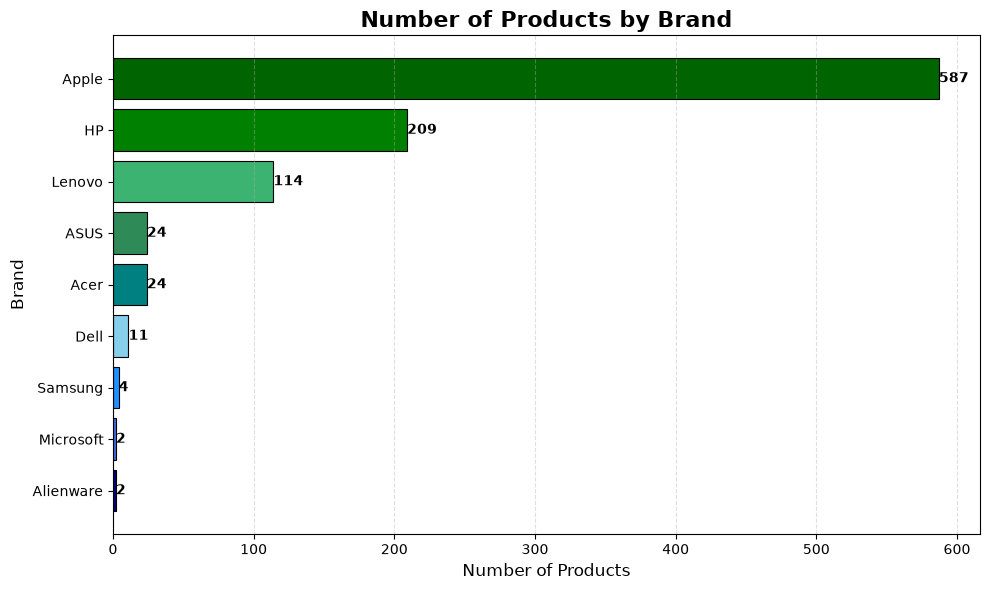

In [12]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 6))

# Number of products for each brand
brand_count = df["Brand"].value_counts().sort_values()

colors = [
    "navy",
    "royalblue",
    "dodgerblue",
    "skyblue",
    "teal",
    "seagreen",
    "mediumseagreen",
    "green",
    "darkgreen"
]

# Bar chart
bars = ax.barh(
    brand_count.index,
    brand_count.values,
    color=colors[:len(brand_count)],
    edgecolor="black",
    linewidth=0.8
)

# Title and labels
ax.set_title(
    "Number of Products by Brand",
    fontweight="bold",
    fontsize=16
)

ax.set_xlabel("Number of Products", fontsize=12)
ax.set_ylabel("Brand", fontsize=12)

# Add count at end of each bar
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontweight="bold"
    )

# Grid
ax.grid(
    axis="x",
    alpha=0.4,
    linestyle="--"
)

plt.tight_layout()
plt.show()

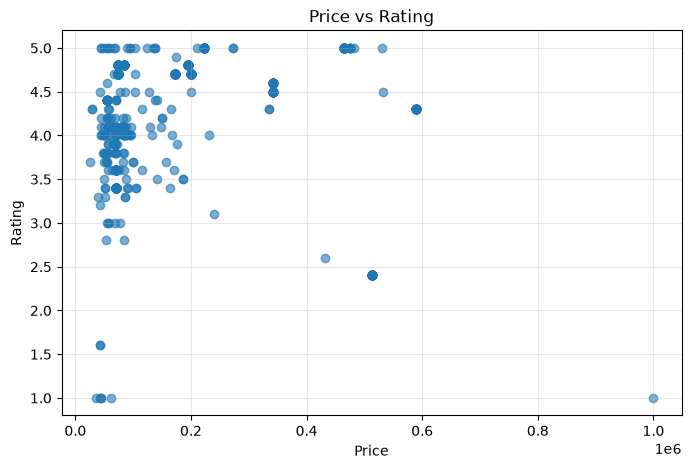

In [13]:

plt.figure(figsize=(8, 5))
plt.scatter(df["Price"], df["Rating"], alpha=0.6)
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.grid(alpha=0.3)
plt.show()

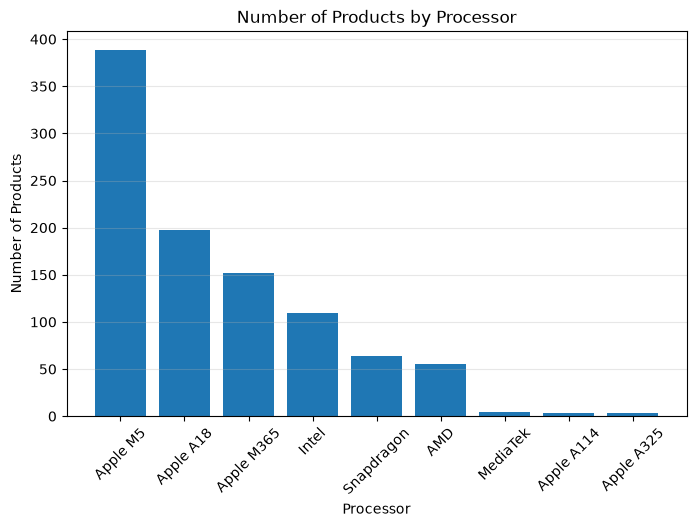

In [14]:
processor_counts = df["Processor"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(processor_counts.index.astype(str), processor_counts.values)
plt.title("Number of Products by Processor")
plt.xlabel("Processor")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


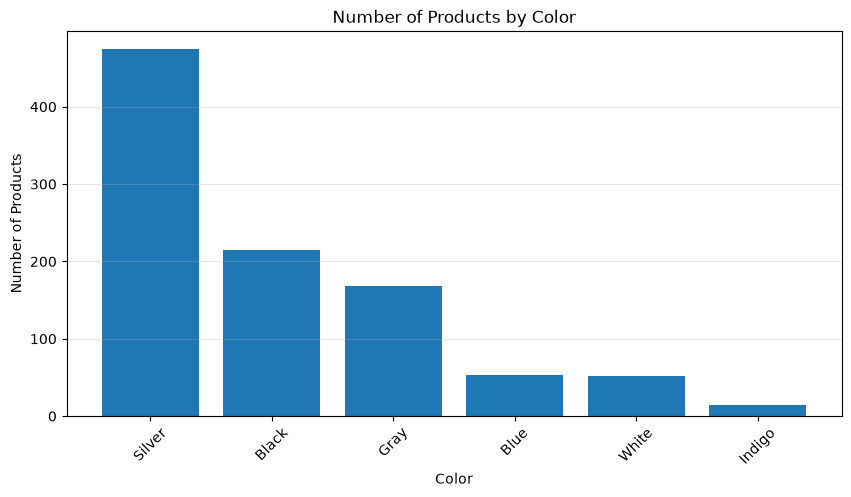

In [15]:
color_counts = df["Color"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(color_counts.index.astype(str), color_counts.values)
plt.title("Number of Products by Color")
plt.xlabel("Color")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()
